# Regression in Practice: Modelling R&D Tax Relief Expenditure

In the [previous post](https://analytax.ai/2026/02/07/regression-explained-for-tax.html), I explained what regression is, how it works conceptually, and where it applies in tax and finance. This post takes the next step: **building a working regression model from scratch**, using Python and a synthetic dataset modelled on UK R&D tax relief claims.

The scenario is straightforward. We have data on 120 company-year R&D claims. For each, we know the cost drivers — headcount, salaries, subcontractor spend, consumables, software costs, number of projects, and the proportion of time spent on qualifying activities. We want to model the relationship between these drivers and total qualifying R&D expenditure.

This is exactly the kind of analysis a tax team might run to:
- **Sense-check claims** — does the qualifying expenditure look proportionate to the underlying activity?
- **Identify anomalies** — which claims deviate significantly from what the model predicts?
- **Understand cost drivers** — which factors contribute most to qualifying spend?

We'll work through the full workflow: loading and exploring the data, fitting a simple regression with one predictor, extending to multiple regression, interpreting the output, and diagnosing problems. Everything maps directly to the theory covered in the previous post.

## Setup

We need just a few standard libraries. If you're following along, these are all available via `pip install`.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

## Loading the Data

The dataset is a synthetic collection of 120 company-year R&D tax relief records. Each row represents one company's claim for one year. The data was generated with realistic relationships between cost drivers and qualifying expenditure, based on how UK R&D tax relief actually works.

The variables are:

| Variable | Description |
|---|---|
| `rd_headcount` | Number of R&D staff (FTEs) |
| `avg_salary` | Average salary of R&D staff (£) |
| `subcontractor_costs` | Spend on external R&D subcontractors (£) |
| `consumables_spend` | Materials and consumables used in R&D (£) |
| `software_costs` | Software and cloud costs attributable to R&D (£) |
| `num_projects` | Number of active R&D projects |
| `pct_time_qualifying` | Proportion of staff time on qualifying R&D activities |
| `qualifying_rd_expenditure` | Total qualifying R&D expenditure (£) — **this is what we want to model** |

In [20]:
df = pd.read_csv("../assets/data/rd_tax_relief.csv")
df = df.drop(columns=["record_id"])  # Not a feature

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)

Dataset: 120 rows, 8 columns


,rd_headcount,avg_salary,subcontractor_costs,consumables_spend,software_costs,num_projects,pct_time_qualifying,qualifying_rd_expenditure
0,31,35000,0,11563,3254,1,0.50,494752
1,10,37434,0,5000,2000,1,0.69,262598
2,46,41359,9225,28426,18414,1,0.66,1372587
3,54,51273,36592,25116,14194,1,0.67,1663527
4,5,42180,500000,5000,2716,7,0.67,437854
5,8,38654,47462,14054,4222,1,0.67,271142
6,27,49406,202776,8824,16318,1,0.92,1407036
7,18,35000,40531,35144,2000,8,0.62,466772
8,24,35000,72906,23924,8620,12,0.69,743432
9,11,35000,33923,5000,2000,1,0.61,272142


## Exploring the Data

Before fitting any model, we need to understand what we're working with. This is a step that's easy to skip when an LLM generates your code, but it's essential. You can't interpret a regression if you don't know what the data looks like.

In [21]:
df.describe().round(0)

,rd_headcount,avg_salary,subcontractor_costs,consumables_spend,software_costs,num_projects,pct_time_qualifying,qualifying_rd_expenditure
count,120.0,120.0,120.0,120.0,120.0,120.0,120.0,120.0
mean,28.0,39632.0,50482.0,21201.0,12503.0,4.0,1.0,856479.0
std,21.0,6017.0,100672.0,20112.0,8560.0,3.0,0.0,678260.0
min,5.0,35000.0,0.0,5000.0,2000.0,1.0,0.0,155715.0
25%,15.0,35000.0,0.0,8346.0,5534.0,1.0,1.0,442094.0
50%,24.0,37168.0,12794.0,17517.0,12114.0,4.0,1.0,664456.0
75%,37.0,42677.0,49564.0,26786.0,17142.0,6.0,1.0,1143126.0
max,151.0,60610.0,500000.0,148831.0,55735.0,13.0,1.0,5308506.0


A few things to notice:
- **R&D headcount** ranges from single digits to over 100 — a wide spread, which is good for regression.
- **Subcontractor costs** have a minimum of zero — some companies do all R&D in-house.
- **Qualifying expenditure** (our target) ranges from around £150k to over £5m. There's substantial variation to explain.

Let's look at the distribution of our target variable.

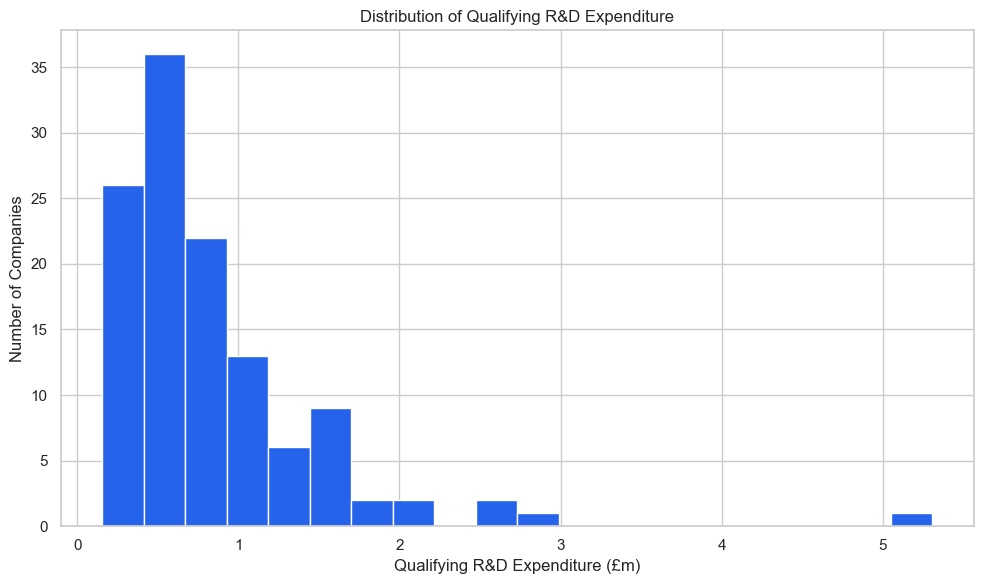

In [22]:
fig, ax = plt.subplots()
ax.hist(df["qualifying_rd_expenditure"] / 1e6, bins=20, edgecolor="white", color="#2563eb")
ax.set_xlabel("Qualifying R&D Expenditure (£m)")
ax.set_ylabel("Number of Companies")
ax.set_title("Distribution of Qualifying R&D Expenditure")
plt.tight_layout()
plt.show()

The distribution is right-skewed — most claims are under £1m, with a tail of larger claims. This is typical of R&D expenditure data: many small-to-mid-size claimants and a few large ones.

Now let's see how each feature correlates with qualifying expenditure.

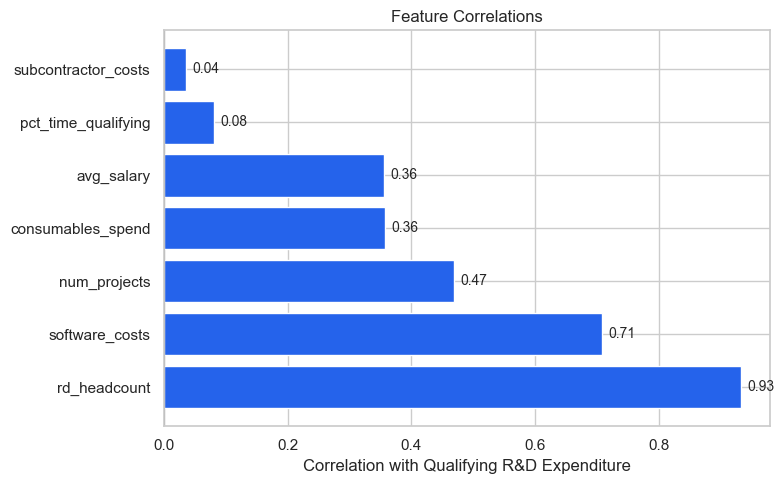

In [23]:
correlations = df.corr()["qualifying_rd_expenditure"].drop("qualifying_rd_expenditure").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2563eb" if v > 0 else "#dc2626" for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, edgecolor="white")
ax.set_xlabel("Correlation with Qualifying R&D Expenditure")
ax.set_title("Feature Correlations")
ax.axvline(x=0, color="grey", linewidth=0.8)
for i, v in enumerate(correlations.values):
    ax.text(v + 0.01 if v > 0 else v - 0.06, i, f"{v:.2f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

**R&D headcount is by far the strongest single predictor.** This makes intuitive sense: staff costs are the largest component of most R&D claims. Software costs and the number of projects also show meaningful correlations, partly because they tend to scale with headcount.

Notice that subcontractor costs and percentage of qualifying time show weaker correlations. This doesn't mean they're unimportant — it may mean their relationship with the outcome is more conditional or moderated by other factors. Multiple regression will help us disentangle this.

Let's also look at the correlation matrix between all features to understand multicollinearity — the extent to which predictors are correlated with each other.

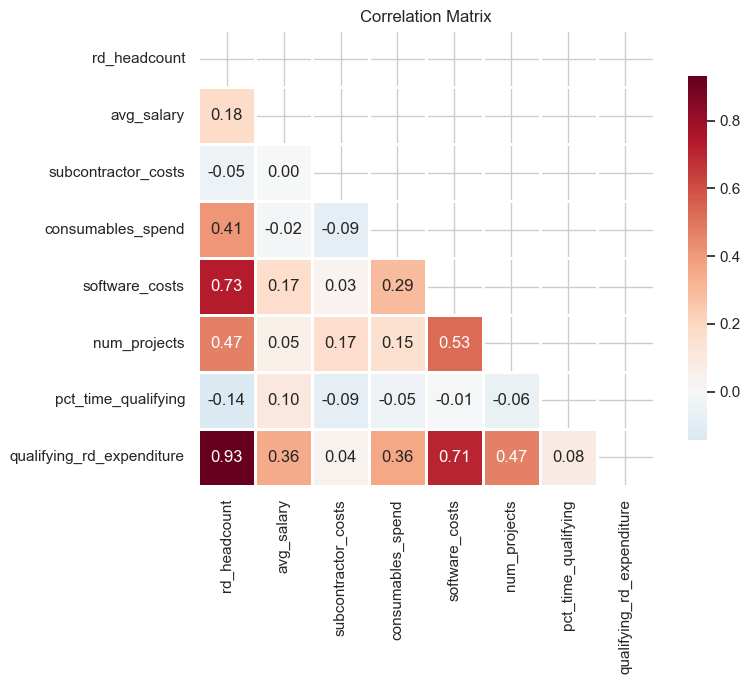

In [24]:
fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, square=True, linewidths=1, ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

The heatmap confirms what we'd expect: `rd_headcount`, `software_costs`, and `num_projects` are inter-correlated (larger R&D teams tend to have more projects and higher software spend). This is worth noting — when predictors are correlated with each other, the individual coefficients in a multiple regression can be harder to interpret precisely. We'll return to this point later.

## Simple Linear Regression: One Predictor

Let's start with the simplest case — modelling qualifying R&D expenditure using just R&D headcount. This is the "line of best fit" from the previous post.

Before fitting, we'll split the data into training and test sets. The model learns from the training data; we evaluate it on the test data it hasn't seen. This is the most basic defence against overfitting.

In [25]:
# Define features and target
X_simple = df[["rd_headcount"]]
y = df["qualifying_rd_expenditure"]

# Split: 80% train, 20% test
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train_s.shape[0]} rows")
print(f"Test set:     {X_test_s.shape[0]} rows")

Training set: 96 rows
Test set:     24 rows


In [26]:
# Fit simple linear regression
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train)

# Coefficients
intercept = model_simple.intercept_
slope = model_simple.coef_[0]

print(f"Equation: qualifying_rd_expenditure = {intercept:,.0f} + {slope:,.0f} × rd_headcount")
print(f"\nInterpretation:")
print(f"  - Intercept (β₀): £{intercept:,.0f} — baseline expenditure with zero headcount")
print(f"  - Slope (β₁):     £{slope:,.0f} — each additional R&D FTE adds this much to qualifying spend")

Equation: qualifying_rd_expenditure = -17,257 + 30,639 × rd_headcount

Interpretation:
  - Intercept (β₀): £-17,257 — baseline expenditure with zero headcount
  - Slope (β₁):     £30,639 — each additional R&D FTE adds this much to qualifying spend


The slope tells us that each additional R&D FTE is associated with roughly an increase in qualifying expenditure. Does this make sense? If the average salary is around £40,000 and roughly 70% of time is qualifying, then the expected staff cost per FTE is about £28,000 — but there are also consumables, software, and other costs that scale with headcount. The coefficient captures the total marginal effect, not just salary.

Let's visualise the fit.

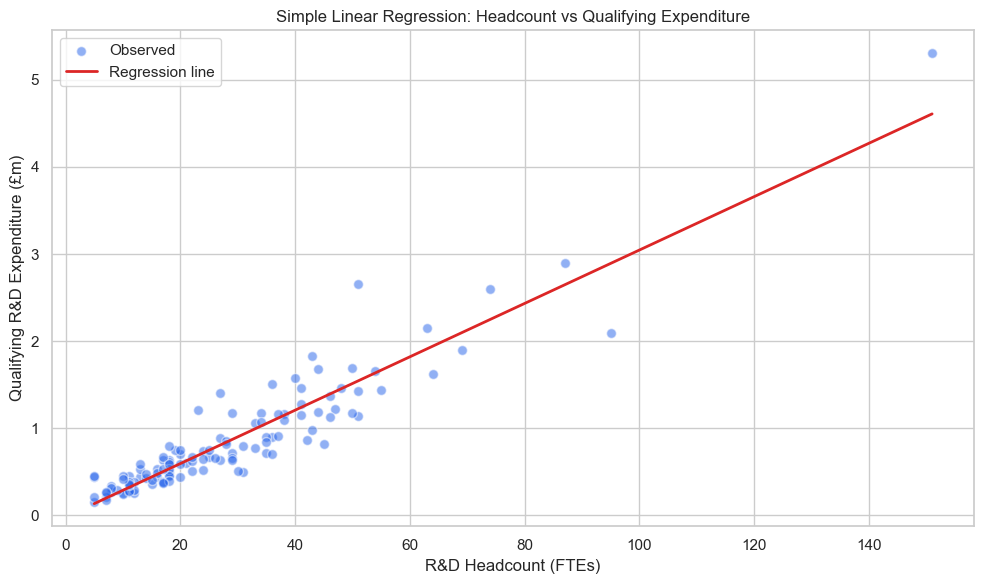

In [27]:
# Predictions across the range
x_range = pd.DataFrame(
    np.linspace(df["rd_headcount"].min(), df["rd_headcount"].max(), 100),
    columns=["rd_headcount"]
)
y_pred_line = model_simple.predict(x_range)

fig, ax = plt.subplots()
ax.scatter(df["rd_headcount"], df["qualifying_rd_expenditure"] / 1e6,
           alpha=0.5, color="#2563eb", edgecolors="white", s=50, label="Observed")
ax.plot(x_range["rd_headcount"], y_pred_line / 1e6, color="#dc2626", linewidth=2, label="Regression line")
ax.set_xlabel("R&D Headcount (FTEs)")
ax.set_ylabel("Qualifying R&D Expenditure (£m)")
ax.set_title("Simple Linear Regression: Headcount vs Qualifying Expenditure")
ax.legend()
plt.tight_layout()
plt.show()

The line tracks the general trend well, but there's clear scatter around it — especially for larger companies. This is exactly what we'd expect: headcount alone doesn't capture everything. Salary levels, subcontractor usage, and time allocation all vary across companies.

Let's quantify how well this simple model performs.

In [28]:
# Evaluate on test set
y_pred_test_s = model_simple.predict(X_test_s)

r2_train_s = model_simple.score(X_train_s, y_train)
r2_test_s = r2_score(y_test, y_pred_test_s)
mae_test_s = mean_absolute_error(y_test, y_pred_test_s)
rmse_test_s = np.sqrt(mean_squared_error(y_test, y_pred_test_s))

print(f"Simple Model Performance")
print(f"{'='*40}")
print(f"R² (train): {r2_train_s:.3f}")
print(f"R² (test):  {r2_test_s:.3f}")
print(f"MAE (test): £{mae_test_s:,.0f}")
print(f"RMSE (test): £{rmse_test_s:,.0f}")

Simple Model Performance
R² (train): 0.900
R² (test):  0.653
MAE (test): £204,705
RMSE (test): £309,710


**What do these numbers mean?**

- **R²** tells us the proportion of variation in qualifying expenditure explained by headcount alone. A training R² around 0.90 looks strong, but the test R² is notably lower — the model loses accuracy on unseen data.
- **MAE** (Mean Absolute Error) is the average prediction error in pounds. This gives a concrete sense of accuracy.
- **RMSE** (Root Mean Squared Error) penalises larger errors more heavily — it's always larger than MAE when errors vary in size.
- The gap between train and test R² tells us that a single predictor, while capturing the broad trend, isn't stable enough on its own. With only one feature, the model is sensitive to which specific companies end up in the test set — especially outliers.

Can we do better by including more predictors? That's where multiple regression comes in.

## Multiple Linear Regression: All Predictors

Now let's use all seven features. In the previous post, this was the jump from fitting a line to fitting a hyperplane — same principle, more dimensions.

In [29]:
# All features
feature_cols = ["rd_headcount", "avg_salary", "subcontractor_costs",
                "consumables_spend", "software_costs", "num_projects",
                "pct_time_qualifying"]

X = df[feature_cols]
y = df["qualifying_rd_expenditure"]

# Same split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit multiple regression
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
# Display coefficients
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model_multi.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print(f"Intercept: £{model_multi.intercept_:,.0f}")
print(f"\nCoefficients:")
print(coef_df.to_string(index=False))

Intercept: £-1,471,171

Coefficients:
            Feature   Coefficient
pct_time_qualifying  1.089716e+06
       rd_headcount  3.089923e+04
       num_projects  8.538909e+03
         avg_salary  1.655596e+01
     software_costs -2.270596e+00
subcontractor_costs  5.413304e-01
  consumables_spend -5.320488e-01


### Interpreting the Coefficients

Each coefficient represents the expected change in qualifying expenditure for a one-unit increase in that feature, **holding all other features constant**. This "all else equal" qualifier is critical.

Let's think about what we'd expect given how R&D tax relief actually works:

- **`rd_headcount`** and **`avg_salary`** should both be strong positive predictors — staff costs dominate most claims.
- **`pct_time_qualifying`** should matter: if only 50% of time qualifies vs 95%, that dramatically changes the eligible staff cost.
- **`subcontractor_costs`** should have a positive coefficient, but the model might learn that it's discounted (under UK rules, only 65% of subcontractor costs qualify for RDEC claims).
- **`consumables_spend`** and **`software_costs`** should be positive but smaller contributors.
- **`num_projects`** is more ambiguous — it's correlated with headcount but doesn't directly drive costs.

Do the actual coefficients match these expectations? This kind of domain-informed sanity check is exactly what the previous post argued for: you need to know enough to ask whether the numbers make sense.

In [31]:
# Evaluate multiple regression
y_pred_test_m = model_multi.predict(X_test)

r2_train_m = model_multi.score(X_train, y_train)
r2_test_m = r2_score(y_test, y_pred_test_m)
mae_test_m = mean_absolute_error(y_test, y_pred_test_m)
rmse_test_m = np.sqrt(mean_squared_error(y_test, y_pred_test_m))

print(f"Multiple Regression Performance")
print(f"{'='*40}")
print(f"R² (train): {r2_train_m:.3f}")
print(f"R² (test):  {r2_test_m:.3f}")
print(f"MAE (test): £{mae_test_m:,.0f}")
print(f"RMSE (test): £{rmse_test_m:,.0f}")
print(f"\n--- Comparison with simple model ---")
print(f"R² improvement:  {r2_test_m - r2_test_s:+.3f}")
print(f"MAE reduction:   £{mae_test_s - mae_test_m:,.0f}")
print(f"RMSE reduction:  £{rmse_test_s - rmse_test_m:,.0f}")

Multiple Regression Performance
R² (train): 0.966
R² (test):  0.875
MAE (test): £112,204
RMSE (test): £185,619

--- Comparison with simple model ---
R² improvement:  +0.223
MAE reduction:   £92,501
RMSE reduction:  £124,091


The multiple regression model should show a meaningful improvement over the simple model — more variation explained, lower prediction errors. The additional features are contributing real explanatory power.

But the raw scikit-learn output doesn't give us statistical significance. For that, we need `statsmodels`, which provides the full regression summary table that a statistician (or a tax director asking pointed questions) would expect to see.

## Statistical Significance: The Full Regression Summary

The `statsmodels` library gives us p-values, confidence intervals, and diagnostic statistics — everything we discussed in the theory post. Let's fit the same model using `statsmodels` and examine the output.

In [32]:
# Fit using statsmodels for full statistical output
X_train_sm = sm.add_constant(X_train)  # statsmodels requires explicit intercept
ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                                OLS Regression Results                               
Dep. Variable:     qualifying_rd_expenditure   R-squared:                       0.966
Model:                                   OLS   Adj. R-squared:                  0.963
Method:                        Least Squares   F-statistic:                     353.1
Date:                       Mon, 16 Feb 2026   Prob (F-statistic):           1.55e-61
Time:                               21:17:11   Log-Likelihood:                -1267.5
No. Observations:                         96   AIC:                             2551.
Df Residuals:                             88   BIC:                             2572.
Df Model:                                  7                                         
Covariance Type:                   nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

### Reading the Summary Table

This is the output you'll encounter whenever regression is used seriously. Here's how to read the key parts:

**Top section:**
- **R-squared** and **Adj. R-squared** — the adjusted version penalises adding predictors that don't improve the model. If these are close together, no predictor is redundant.
- **F-statistic** and its p-value — tests whether the model as a whole is statistically significant (i.e., whether at least one predictor matters). A very low p-value means the model is significant.

**Coefficient table:**
- **coef** — the estimated coefficient (β) for each feature.
- **std err** — how precisely the coefficient is estimated. Smaller is better.
- **t** — the coefficient divided by its standard error. Larger absolute values indicate stronger evidence.
- **P>|t|** — the p-value. Below 0.05 conventionally means "statistically significant." But don't treat 0.05 as a magic threshold — a predictor with p=0.06 isn't meaningfully different from one with p=0.04.
- **[0.025, 0.975]** — the 95% confidence interval for the coefficient.

**What to look for:**
- Which features have low p-values? These are the reliable predictors.
- Which features have high p-values? These may not be contributing meaningfully — consider whether they should stay in the model.
- Do the coefficient signs and magnitudes match your domain knowledge about how R&D tax relief works?

## Model Diagnostics: Can We Trust the Results?

A model that appears to fit well can still be misleading if the underlying assumptions of linear regression are violated. The previous post mentioned that residuals should be "small and randomly scattered." Let's check.

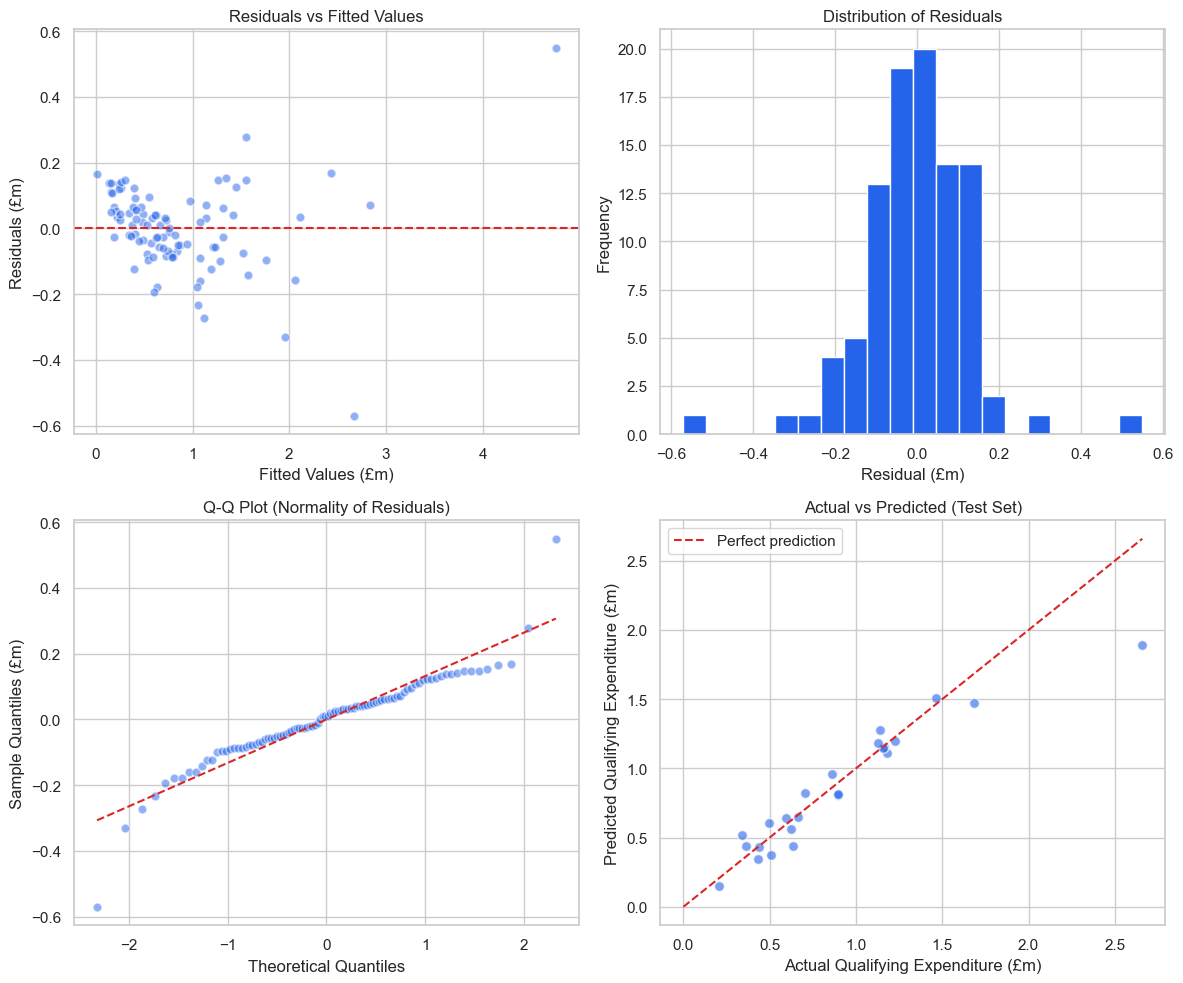

In [33]:
# Calculate residuals on training data
y_pred_train = model_multi.predict(X_train)
residuals = y_train - y_pred_train

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(y_pred_train / 1e6, residuals / 1e6, alpha=0.5, color="#2563eb", edgecolors="white", s=40)
axes[0, 0].axhline(y=0, color="#dc2626", linewidth=1.5, linestyle="--")
axes[0, 0].set_xlabel("Fitted Values (£m)")
axes[0, 0].set_ylabel("Residuals (£m)")
axes[0, 0].set_title("Residuals vs Fitted Values")

# 2. Histogram of residuals
axes[0, 1].hist(residuals / 1e6, bins=20, edgecolor="white", color="#2563eb")
axes[0, 1].set_xlabel("Residual (£m)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Distribution of Residuals")

# 3. Q-Q plot
from scipy import stats
sorted_residuals = np.sort(residuals)
theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, len(sorted_residuals)))
axes[1, 0].scatter(theoretical_quantiles, sorted_residuals / 1e6, alpha=0.5, color="#2563eb", edgecolors="white", s=40)
# Reference line
z_line = np.linspace(theoretical_quantiles.min(), theoretical_quantiles.max(), 100)
axes[1, 0].plot(z_line, z_line * (residuals.std() / 1e6), color="#dc2626", linewidth=1.5, linestyle="--")
axes[1, 0].set_xlabel("Theoretical Quantiles")
axes[1, 0].set_ylabel("Sample Quantiles (£m)")
axes[1, 0].set_title("Q-Q Plot (Normality of Residuals)")

# 4. Actual vs Predicted
axes[1, 1].scatter(y_test / 1e6, y_pred_test_m / 1e6, alpha=0.6, color="#2563eb", edgecolors="white", s=50)
max_val = max(y_test.max(), y_pred_test_m.max()) / 1e6
axes[1, 1].plot([0, max_val], [0, max_val], color="#dc2626", linewidth=1.5, linestyle="--", label="Perfect prediction")
axes[1, 1].set_xlabel("Actual Qualifying Expenditure (£m)")
axes[1, 1].set_ylabel("Predicted Qualifying Expenditure (£m)")
axes[1, 1].set_title("Actual vs Predicted (Test Set)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### What to look for in each plot

**Residuals vs Fitted Values (top-left):** If the model is well-specified, residuals should form a random cloud centred on zero. Patterns — such as a funnel shape (residuals growing with fitted values) or a curve — suggest problems. A funnel shape would indicate *heteroscedasticity* (non-constant variance), which means the model is less reliable for larger predictions.

**Distribution of Residuals (top-right):** Linear regression assumes residuals are approximately normally distributed. A roughly bell-shaped histogram is reassuring. Heavy skew or multiple peaks suggest the model is systematically missing something.

**Q-Q Plot (bottom-left):** Another way to check normality. If residuals are normally distributed, points should fall close to the diagonal line. Deviations at the tails indicate the residuals have heavier or lighter tails than expected — often caused by outliers.

**Actual vs Predicted (bottom-right):** Points clustered tightly around the diagonal line indicate accurate predictions. Systematic departures — such as the model consistently under-predicting large values — reveal bias.

## Identifying Anomalies: Which Claims Don't Fit the Pattern?

One of the most practical applications of regression in tax is anomaly detection. Once we have a model of "what qualifying expenditure should look like given the cost drivers," any claim that deviates substantially from the prediction is worth investigating.

Let's flag the records with the largest residuals.

In [34]:
# Calculate residuals on the full dataset
y_pred_all = model_multi.predict(X)
df_results = df.copy()
df_results["predicted"] = y_pred_all
df_results["residual"] = y - y_pred_all
df_results["pct_deviation"] = (df_results["residual"] / df_results["predicted"]) * 100

# Top 5 over-predictions (actual << predicted: possible under-claiming?)
print("Top 5 OVER-predictions (model expects more than actual):")
print("These claims may be UNDER-CLAIMING relative to their cost drivers.\n")
over = df_results.nsmallest(5, "residual")[["rd_headcount", "avg_salary", "pct_time_qualifying",
                                              "qualifying_rd_expenditure", "predicted", "residual", "pct_deviation"]]
over.columns = ["Headcount", "Avg Salary", "% Qualifying", "Actual (£)", "Predicted (£)", "Residual (£)", "% Deviation"]
print(over.to_string(index=False))

print("\n")

# Top 5 under-predictions (actual >> predicted: possible over-claiming?)
print("Top 5 UNDER-predictions (actual exceeds model expectation):")
print("These claims may warrant closer review — expenditure is HIGHER than cost drivers suggest.\n")
under = df_results.nlargest(5, "residual")[["rd_headcount", "avg_salary", "pct_time_qualifying",
                                              "qualifying_rd_expenditure", "predicted", "residual", "pct_deviation"]]
under.columns = ["Headcount", "Avg Salary", "% Qualifying", "Actual (£)", "Predicted (£)", "Residual (£)", "% Deviation"]
print(under.to_string(index=False))

Top 5 OVER-predictions (model expects more than actual):
These claims may be UNDER-CLAIMING relative to their cost drivers.

 Headcount  Avg Salary  % Qualifying  Actual (£)  Predicted (£)   Residual (£)  % Deviation
        95       36000          0.58     2095689   2.665432e+06 -569743.432480   -21.375272
        64       55543          0.50     1628085   1.958749e+06 -330664.309827   -16.881400
        35       35000          0.85      845792   1.117783e+06 -271991.406581   -24.333105
        45       35000          0.50      823121   1.054897e+06 -231775.512055   -21.971398
        10       56139          0.79      414051   6.062082e+05 -192157.240710   -31.698223


Top 5 UNDER-predictions (actual exceeds model expectation):
These claims may warrant closer review — expenditure is HIGHER than cost drivers suggest.

 Headcount  Avg Salary  % Qualifying  Actual (£)  Predicted (£)  Residual (£)  % Deviation
        51       56073          0.77     2659161   1.891523e+06 767637.992271  

This is where regression becomes a practical tool for tax teams. The model doesn't tell you *why* a claim is anomalous — it tells you *which* claims to look at. The investigation — checking whether an outlier is a data entry error, a legitimate edge case, or a genuine compliance issue — still requires human judgement and domain knowledge.

But instead of reviewing all 120 claims manually, you're reviewing 5-10. That's the value proposition.

## Feature Importance: What Drives Qualifying Expenditure?

The raw coefficients are hard to compare directly because the features are on different scales (headcount is 5-200, salary is 35,000-85,000). To understand relative importance, we can look at standardised coefficients — what happens to the prediction when each feature moves by one standard deviation.

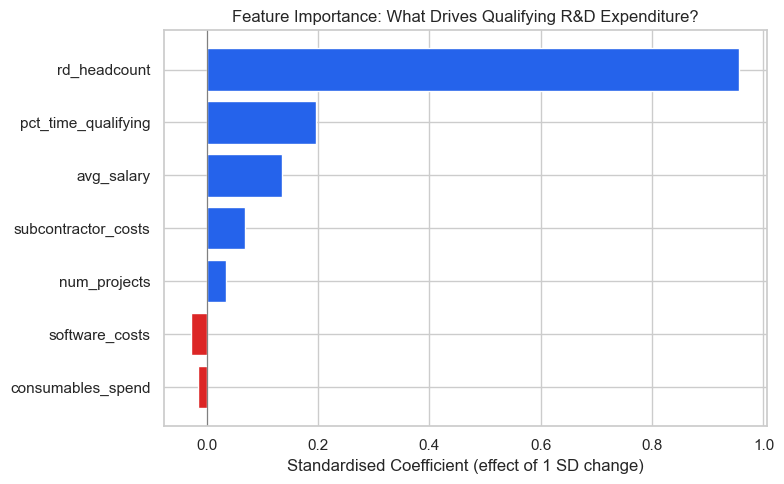

In [35]:
# Standardised coefficients
std_coefs = model_multi.coef_ * X_train.std().values / y_train.std()

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Standardised Coefficient": std_coefs
}).sort_values("Standardised Coefficient", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2563eb" if v > 0 else "#dc2626" for v in importance_df["Standardised Coefficient"]]
ax.barh(importance_df["Feature"], importance_df["Standardised Coefficient"], color=colors, edgecolor="white")
ax.set_xlabel("Standardised Coefficient (effect of 1 SD change)")
ax.set_title("Feature Importance: What Drives Qualifying R&D Expenditure?")
ax.axvline(x=0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.show()

This chart answers the question a tax director would ask: **"What matters most?"** The standardised coefficients put all features on the same scale, so the bars are directly comparable. Features with larger absolute bars have a bigger impact on qualifying expenditure.

For R&D tax relief, we'd expect staff-related factors (headcount, salary, qualifying time percentage) to dominate — and they should. This aligns with the reality that staff costs typically represent 60-80% of an R&D claim.

## Bringing It Together

Let's summarise what we've built and what it tells us.

**What we did:**
1. Loaded a dataset of 120 R&D tax relief claims with 7 cost driver features.
2. Explored the data to understand distributions and correlations.
3. Built a simple regression using only headcount — a reasonable baseline.
4. Extended to multiple regression using all features — a more complete model.
5. Examined statistical significance using the full OLS summary.
6. Diagnosed the model using residual plots.
7. Used the model to flag anomalous claims.
8. Assessed feature importance to understand what drives qualifying expenditure.

**What we learned:**
- R&D headcount is the single strongest predictor, but the full model captures substantially more variation.
- The coefficient magnitudes and signs are interpretable in terms of how UK R&D tax relief actually works.
- Residual analysis highlights claims that deviate from the model's expectations — a practical anomaly detection mechanism.
- Standardised coefficients reveal which cost drivers have the most influence.

**What this doesn't do:**
- This model doesn't prove that any claim is incorrect — it identifies patterns and deviations.
- The coefficients show associations, not causation.
- With 120 observations and 7 predictors, overfitting is a risk — the train/test split helps but isn't a guarantee.

**The broader point:**

None of this code is difficult. The entire workflow — from loading data to diagnosing the model — is about 50 lines of Python. An LLM could generate most of it from a prompt. But knowing *what the output means*, *whether to trust it*, and *what questions to ask* — that's the understanding from the previous post paying off. The code is the easy part. The thinking is what matters.

In [36]:
# Final summary table
summary = pd.DataFrame({
    "Metric": ["R² (test)", "MAE (test)", "RMSE (test)", "Number of features"],
    "Simple Model": [f"{r2_test_s:.3f}", f"£{mae_test_s:,.0f}", f"£{rmse_test_s:,.0f}", "1"],
    "Multiple Model": [f"{r2_test_m:.3f}", f"£{mae_test_m:,.0f}", f"£{rmse_test_m:,.0f}", "7"]
})
print(summary.to_string(index=False))

            Metric Simple Model Multiple Model
         R² (test)        0.653          0.875
        MAE (test)     £204,705       £112,204
       RMSE (test)     £309,710       £185,619
Number of features            1              7
